In [ ]:
import os
import time
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.preprocessing import OneHotEncoder
from scipy.stats import norm
import sys
from multiprocessing import Pool, cpu_count
from functools import partial
from sklearn.utils import resample

sys.path.append('./BTHOWeN/software_model')
from wisard import WiSARD

# ==========================================================
# BALANCEAMENTO
# ==========================================================
def balance_dataset_undersample(X, y):
    X, y = np.array(X), np.array(y)
    unique = np.unique(y)
    class_min = unique[0] if np.sum(y == unique[0]) < np.sum(y == unique[1]) else unique[1]
    class_maj = 1 - class_min if set(unique) == {0,1} else (unique[0] if class_min == unique[1] else unique[1])
    count_min = np.sum(y == class_min)
    idx_min = np.where(y == class_min)[0]
    idx_maj = np.where(y == class_maj)[0]
    idx_maj_bal = resample(idx_maj, replace=False, n_samples=count_min, random_state=42)
    balanced_idx = np.concatenate([idx_min, idx_maj_bal])
    np.random.shuffle(balanced_idx)
    return X[balanced_idx], y[balanced_idx]

def balance_dataset_oversample(X, y):
    X, y = np.array(X), np.array(y)
    unique = np.unique(y)
    class_min = unique[0] if np.sum(y == unique[0]) < np.sum(y == unique[1]) else unique[1]
    class_maj = 1 - class_min if set(unique) == {0,1} else (unique[0] if class_min == unique[1] else unique[1])
    count_maj = np.sum(y == class_maj)
    idx_min = np.where(y == class_min)[0]
    idx_maj = np.where(y == class_maj)[0]
    idx_min_over = resample(idx_min, replace=True, n_samples=count_maj, random_state=42)
    balanced_idx = np.concatenate([idx_min_over, idx_maj])
    np.random.shuffle(balanced_idx)
    return X[balanced_idx], y[balanced_idx]

# ==========================================================
# BINARIZAÇÃO (SEM DATA LEAKAGE)
# ==========================================================
def encode_features(X_tr, X_val, X_te, bpt):
    """
    Calcula médias/desvios/categorias APENAS no X_tr e aplica em X_tr, X_val e X_te.
    """
    X_tr_parts, X_val_parts, X_te_parts = [], [], []
    
    for col in X_tr.columns:
        s_tr = X_tr[col]
        s_val = X_val[col]
        s_te = X_te[col]
        
        if s_tr.dtype == 'object' or s_tr.dtype.name == 'string':
            s_tr = s_tr.astype(str).str.strip().str.lower()
            s_val = s_val.astype(str).str.strip().str.lower()
            s_te = s_te.astype(str).str.strip().str.lower()
            
        nunique = s_tr.nunique()
        
        if nunique <= 1:
            continue
            
        elif nunique == 2:
            # Binarização Direta
            valores_unicos = sorted(s_tr.dropna().unique())
            mapeamento = {valores_unicos[0]: 0, valores_unicos[1]: 1}
            X_tr_parts.append(s_tr.map(mapeamento).fillna(0).astype(int).values.reshape(-1, 1))
            X_val_parts.append(s_val.map(mapeamento).fillna(0).astype(int).values.reshape(-1, 1))
            X_te_parts.append(s_te.map(mapeamento).fillna(0).astype(int).values.reshape(-1, 1))
            
        elif pd.api.types.is_numeric_dtype(s_tr):
            val_tr = pd.to_numeric(s_tr, errors='coerce').fillna(0).values.astype(float)
            media, desvio = np.mean(val_tr), np.std(val_tr)
            limiares = norm.ppf(np.linspace(0, 1, bpt + 2)[1:-1], loc=media, scale=desvio) if desvio > 0 else []
            
            def aplica_gauss(serie):
                val = pd.to_numeric(serie, errors='coerce').fillna(0).values.astype(float)
                if desvio == 0:
                    return np.zeros((len(val), bpt), dtype=int)
                return np.array([
                    [1] * np.sum(v > limiares) + [0] * (bpt - np.sum(v > limiares))
                    for v in val
                ], dtype=int)
            
            X_tr_parts.append(aplica_gauss(s_tr))
            X_val_parts.append(aplica_gauss(s_val))
            X_te_parts.append(aplica_gauss(s_te))
            
        else:
            # One-Hot Encoding
            enc = OneHotEncoder(handle_unknown='ignore', sparse_output=False, dtype=int)
            X_tr_parts.append(enc.fit_transform(s_tr.values.reshape(-1, 1)))
            X_val_parts.append(enc.transform(s_val.values.reshape(-1, 1)))
            X_te_parts.append(enc.transform(s_te.values.reshape(-1, 1)))
            
    return np.hstack(X_tr_parts), np.hstack(X_val_parts), np.hstack(X_te_parts)

# ==========================================================
# FUNÇÃO DE AVALIAÇÃO
# ==========================================================
def evaluate_config(params, X_tr, y_tr, X_val, y_val):
    """
    params: (unit_inputs, unit_entries, unit_hashes)
    Treina o modelo e encontra o melhor bleach usando busca binária adaptativa
    sobre o conjunto de validação.
    Retorna: (unit_inputs, unit_entries, unit_hashes, best_bleach, best_acc, best_f1)
    """
    unit_inputs, unit_entries, unit_hashes = params
    modelo = WiSARD(X_tr.shape[1], 2, unit_inputs, unit_entries, unit_hashes)
    
    # Treinamento
    for i in range(len(X_tr)):
        modelo.train(X_tr[i], int(y_tr[i]))
    
    max_val = 0
    for d in modelo.discriminators:
        for f in d.filters:
            max_val = max(max_val, f.data.max())
    
    if max_val <= 1:
        best_bleach = 1
        y_pred = []
        for i in range(len(X_val)):
            pred = modelo.predict(X_val[i])
            y_pred.append(int(pred[0]) if len(pred) == 1 else np.random.choice(pred))
        best_acc = accuracy_score(y_val, y_pred)
        best_f1 = f1_score(y_val, y_pred, zero_division=0)
        return (unit_inputs, unit_entries, unit_hashes, best_bleach, best_acc, best_f1)
    
    best_bleach = max_val // 2
    step = max(max_val // 4, 1)
    bleach_accuracies = {}
    
    while True:
        candidates = [best_bleach - step, best_bleach, best_bleach + step]
        accuracies = []
        for b in candidates:
            if b in bleach_accuracies:
                accuracies.append(bleach_accuracies[b])
            elif b < 1:
                accuracies.append(0)
            else:
                modelo.set_bleaching(b)
                y_pred = []
                for i in range(len(X_val)):
                    pred = modelo.predict(X_val[i])
                    y_pred.append(int(pred[0]) if len(pred) == 1 else np.random.choice(pred))
                acc = accuracy_score(y_val, y_pred)
                bleach_accuracies[b] = acc
                accuracies.append(acc)
        
        new_best = candidates[accuracies.index(max(accuracies))]
        if (new_best == best_bleach) and (step == 1):
            break
        best_bleach = new_best
        if step > 1:
            step //= 2
    
    modelo.set_bleaching(best_bleach)
    y_pred_final = []
    for i in range(len(X_val)):
        pred = modelo.predict(X_val[i])
        y_pred_final.append(int(pred[0]) if len(pred) == 1 else np.random.choice(pred))
    best_acc = accuracy_score(y_val, y_pred_final)
    best_f1 = f1_score(y_val, y_pred_final, zero_division=0)
    
    return (unit_inputs, unit_entries, unit_hashes, best_bleach, best_acc, best_f1)

# ==========================================================
# CONFIGURAÇÕES
# ==========================================================
caminho_datasets = "./Datasets"
arquivos = [
    "IoT_Fridge.csv",
    "IoT_Garage_Door.csv",
    "IoT_GPS_Tracker.csv",
    "IoT_Modbus.csv",
    "IoT_Motion_Light.csv",
    "IoT_Thermostat.csv",
    "IoT_Weather.csv"
]

bits_por_termo = [4, 8, 16]
input_bits_filtro = [4, 8, 16, 24]
entries_filtro = [128, 256, 512, 1024, 2048]
hash_functions = [2, 3]
balance_method = 'undersample'

resultados_finais = []

print("INICIANDO AVALIAÇÃO - BUSCA ADAPTATIVA DO BLEACHING")
print(f"Bits por termômetro: {bits_por_termo}")
print(f"Inputs por filtro: {input_bits_filtro}")
print(f"Entries por filtro: {entries_filtro}")
print(f"Hash functions: {hash_functions}")
print(f"Balanceamento: {balance_method}\n")

for arquivo in arquivos:
    nome_sensor = arquivo.replace("IoT_", "").replace(".csv", "")
    print(f"\n🔄 Processando {nome_sensor.upper()}...")

    # Carrega e limpa dados
    df = pd.read_csv(os.path.join(caminho_datasets, arquivo), low_memory=False)
    df.columns = df.columns.str.strip()
    for col in ['date','time','ts','timestamp']:
        if col in df.columns: df.drop(columns=col, inplace=True)
    if 'sphone_signal' in df.columns:
        df['sphone_signal'] = df['sphone_signal'].astype(str).str.strip().str.lower().replace({'0':'false','0.0':'false','1':'true','1.0':'true'})
    
    label_col = [c for c in df.columns if 'label' in c.lower()][0]
    y = df[label_col].values.astype(int)
    X_raw = df.drop(columns=[c for c in df.columns if 'label' in c.lower() or 'type' in c.lower()], errors='ignore')

    # Separação: teste (20%), treino+validação (80%)
    X_raw_tr_full, X_raw_te, y_tr_full, y_te = train_test_split(X_raw, y, test_size=0.2, random_state=42, stratify=y)
    X_raw_tr, X_raw_val, y_tr, y_val = train_test_split(X_raw_tr_full, y_tr_full, test_size=0.2, random_state=42, stratify=y_tr_full)

    melhor_global = None  # (bpt, ui, entries, hashes, bleach, val_acc, val_f1, X_tr_bal, y_tr_bal, X_te_bin)

    for bpt in bits_por_termo:
        print(f"  Bits por termômetro = {bpt}")

        X_tr_bin, X_val_bin, X_te_bin = encode_features(X_raw_tr, X_raw_val, X_raw_te, bpt)
        num_inputs_total = X_tr_bin.shape[1]
        
        if balance_method == 'undersample':
            X_tr_bal, y_tr_bal = balance_dataset_undersample(X_tr_bin, y_tr)
        else:
            X_tr_bal, y_tr_bal = balance_dataset_oversample(X_tr_bin, y_tr)

        combinacoes = []
        for ui in input_bits_filtro:
            ui_eff = max(1, min(ui, num_inputs_total))
            for entries in entries_filtro:
                for hashes in hash_functions:
                    combinacoes.append((ui_eff, entries, hashes))

        num_workers = min(cpu_count(), len(combinacoes))
        eval_partial = partial(evaluate_config, X_tr=X_tr_bal, y_tr=y_tr_bal, X_val=X_val_bin, y_val=y_val)
        
        with Pool(num_workers) as pool:
            resultados = pool.map(eval_partial, combinacoes)

        for (ui, entries, hashes, bleach, acc, f1) in resultados:
            if melhor_global is None or (f1 > melhor_global[6]) or (f1 == melhor_global[6] and acc > melhor_global[5]):
                melhor_global = (bpt, ui, entries, hashes, bleach, acc, f1, X_tr_bal, y_tr_bal, X_te_bin)

        print(f"    Melhor atual (bits={bpt}): Val_F1={melhor_global[6]:.4f}, Val_Acc={melhor_global[5]:.4f}")

    # ==========================================================
    # AVALIAÇÃO FINAL
    # ==========================================================
    bpt, ui, entries, hashes, bleach, _, _, X_tr_bal, y_tr_bal, X_te_bin = melhor_global
    
    # Treinamento com a melhor configuração
    modelo_final = WiSARD(X_tr_bal.shape[1], 2, ui, entries, hashes)
    start_train = time.time()
    for i in range(len(X_tr_bal)):
        modelo_final.train(X_tr_bal[i], int(y_tr_bal[i]))
    train_t = time.time() - start_train

    modelo_final.set_bleaching(bleach)
    preds = []
    start_test = time.time()
    for i in range(len(X_te_bin)):
        pred = modelo_final.predict(X_te_bin[i])
        preds.append(int(pred[0]) if len(pred) == 1 else np.random.choice(pred))
    test_t = time.time() - start_test

    # Métricas
    test_acc = accuracy_score(y_te, preds)
    test_prec = precision_score(y_te, preds, zero_division=0)
    test_rec = recall_score(y_te, preds, zero_division=0)
    test_f1 = f1_score(y_te, preds, zero_division=0)
    cm = confusion_matrix(y_te, preds)

    print(f"  Teste Real - Matriz de Confusão:\n      TN={cm[0,0]} FP={cm[0,1]}\n      FN={cm[1,0]} TP={cm[1,1]}")

    resultados_finais.append({
        'Dataset': nome_sensor.capitalize(),
        'Accuracy': test_acc,
        'Precision': test_prec,
        'Recall': test_rec,
        'F-Score': test_f1,
        'Train Time (s)': train_t,
        'Test Time (s)': test_t,
        'Config (T, M, B)': f"T:{ui} M:{entries} B:{bleach} (bits_term={bpt}, hash={hashes})"
    })
    print(f"  Modelo Vencedor avaliado no Teste: {resultados_finais[-1]['Config (T, M, B)']}\n")

# ==========================================================
# TABELA FINAL
# ==========================================================
print("\n" + "="*115)
print(" TABELA DE MÉTRICAS FINAIS")
print("="*115)
df_res = pd.DataFrame(resultados_finais)
for col in ['Accuracy', 'Precision', 'Recall', 'F-Score', 'Train Time (s)', 'Test Time (s)']:
    df_res[col] = df_res[col].apply(lambda x: f"{float(x):.4f}")
print(df_res.to_string(index=False))
print("="*115)

🤖 INICIANDO AVALIAÇÃO - BUSCA ADAPTATIVA DO BLEACHING (ARTIGO ORIGINAL)
Bits por termômetro: [4, 8, 16]
Inputs por filtro: [4, 8, 16, 24]
Entries por filtro: [128, 256, 512, 1024, 2048]
Hash functions: [2, 3]
Balanceamento: undersample


🔄 Processando FRIDGE...
  Bits por termômetro = 4
    Melhor atual (bits=4): Val_F1=0.4668, Val_Acc=0.8268
  Bits por termômetro = 8
    Melhor atual (bits=8): Val_F1=0.5556, Val_Acc=0.7649
  Bits por termômetro = 16
    Melhor atual (bits=16): Val_F1=0.5556, Val_Acc=0.7649
  📊 Teste Real - Matriz de Confusão:
      TN=72837 FP=27329
      FN=0 TP=17250
  🏆 Modelo Vencedor avaliado no Teste: T:8 M:128 B:11398 (bits_term=8, hash=2)


🔄 Processando GARAGE_DOOR...
  Bits por termômetro = 4
    Melhor atual (bits=4): Val_F1=0.2084, Val_Acc=0.5006
  Bits por termômetro = 8
    Melhor atual (bits=8): Val_F1=0.2084, Val_Acc=0.5006
  Bits por termômetro = 16
    Melhor atual (bits=16): Val_F1=0.2084, Val_Acc=0.5006
  📊 Teste Real - Matriz de Confusão:
      TN

In [ ]:
import os
import time
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.preprocessing import OneHotEncoder
from scipy.stats import norm
import sys
from multiprocessing import Pool, cpu_count
from functools import partial
from sklearn.utils import resample

sys.path.append('./BTHOWeN/software_model')
from wisard import WiSARD

# ==========================================================
# BALANCEAMENTO
# ==========================================================
def balance_dataset_undersample(X, y):
    X, y = np.array(X), np.array(y)
    unique = np.unique(y)
    class_min = unique[0] if np.sum(y == unique[0]) < np.sum(y == unique[1]) else unique[1]
    class_maj = 1 - class_min if set(unique) == {0,1} else (unique[0] if class_min == unique[1] else unique[1])
    count_min = np.sum(y == class_min)
    idx_min = np.where(y == class_min)[0]
    idx_maj = np.where(y == class_maj)[0]
    idx_maj_bal = resample(idx_maj, replace=False, n_samples=count_min, random_state=42)
    balanced_idx = np.concatenate([idx_min, idx_maj_bal])
    np.random.shuffle(balanced_idx)
    return X[balanced_idx], y[balanced_idx]

def balance_dataset_oversample(X, y):
    X, y = np.array(X), np.array(y)
    unique = np.unique(y)
    class_min = unique[0] if np.sum(y == unique[0]) < np.sum(y == unique[1]) else unique[1]
    class_maj = 1 - class_min if set(unique) == {0,1} else (unique[0] if class_min == unique[1] else unique[1])
    count_maj = np.sum(y == class_maj)
    idx_min = np.where(y == class_min)[0]
    idx_maj = np.where(y == class_maj)[0]
    idx_min_over = resample(idx_min, replace=True, n_samples=count_maj, random_state=42)
    balanced_idx = np.concatenate([idx_min_over, idx_maj])
    np.random.shuffle(balanced_idx)
    return X[balanced_idx], y[balanced_idx]

# ==========================================================
# BINARIZAÇÃO
# ==========================================================
def encode_features(X_tr, X_val, X_te, bpt):
    """
    Calcula médias/desvios/categorias APENAS no X_tr e aplica em X_tr, X_val e X_te.
    Assume que não há NaNs (já foram imputados no dataset consolidado).
    """
    X_tr_parts, X_val_parts, X_te_parts = [], [], []
    
    for col in X_tr.columns:
        s_tr = X_tr[col]
        s_val = X_val[col]
        s_te = X_te[col]
        
        if s_tr.dtype == 'object' or s_tr.dtype.name == 'string':
            s_tr = s_tr.astype(str).str.strip().str.lower()
            s_val = s_val.astype(str).str.strip().str.lower()
            s_te = s_te.astype(str).str.strip().str.lower()
            
        nunique = s_tr.nunique()
        
        if nunique <= 1:
            continue
            
        elif nunique == 2:
            # Binarização Direta
            valores_unicos = sorted(s_tr.dropna().unique())
            mapeamento = {valores_unicos[0]: 0, valores_unicos[1]: 1}
            X_tr_parts.append(s_tr.map(mapeamento).fillna(0).astype(int).values.reshape(-1, 1))
            X_val_parts.append(s_val.map(mapeamento).fillna(0).astype(int).values.reshape(-1, 1))
            X_te_parts.append(s_te.map(mapeamento).fillna(0).astype(int).values.reshape(-1, 1))
            
        elif pd.api.types.is_numeric_dtype(s_tr):
            val_tr = pd.to_numeric(s_tr, errors='coerce').fillna(0).values.astype(float)
            media, desvio = np.mean(val_tr), np.std(val_tr)
            if desvio == 0:
                continue
            limiares = norm.ppf(np.linspace(0, 1, bpt + 2)[1:-1], loc=media, scale=desvio)
            
            def aplica_gauss(serie):
                val = pd.to_numeric(serie, errors='coerce').fillna(0).values.astype(float)
                return np.array([
                    [1] * np.sum(v > limiares) + [0] * (bpt - np.sum(v > limiares))
                    for v in val
                ], dtype=int)
            
            X_tr_parts.append(aplica_gauss(s_tr))
            X_val_parts.append(aplica_gauss(s_val))
            X_te_parts.append(aplica_gauss(s_te))
            
        else:
            # One-Hot Encoding
            enc = OneHotEncoder(handle_unknown='ignore', sparse_output=False, dtype=int)
            X_tr_parts.append(enc.fit_transform(s_tr.values.reshape(-1, 1)))
            X_val_parts.append(enc.transform(s_val.values.reshape(-1, 1)))
            X_te_parts.append(enc.transform(s_te.values.reshape(-1, 1)))
    
    if not X_tr_parts:
        return np.empty((len(X_tr), 0)), np.empty((len(X_val), 0)), np.empty((len(X_te), 0))
    
    return np.hstack(X_tr_parts), np.hstack(X_val_parts), np.hstack(X_te_parts)

# ==========================================================
# FUNÇÃO DE AVALIAÇÃO
# ==========================================================
def evaluate_config(params, X_tr, y_tr, X_val, y_val):
    unit_inputs, unit_entries, unit_hashes = params
    modelo = WiSARD(X_tr.shape[1], 2, unit_inputs, unit_entries, unit_hashes)
    
    for i in range(len(X_tr)):
        modelo.train(X_tr[i], int(y_tr[i]))
    
    max_val = 0
    for d in modelo.discriminators:
        for f in d.filters:
            max_val = max(max_val, f.data.max())
    
    if max_val <= 1:
        best_bleach = 1
        y_pred = []
        for i in range(len(X_val)):
            pred = modelo.predict(X_val[i])
            y_pred.append(int(pred[0]) if len(pred) == 1 else np.random.choice(pred))
        best_acc = accuracy_score(y_val, y_pred)
        best_f1 = f1_score(y_val, y_pred, zero_division=0)
        return (unit_inputs, unit_entries, unit_hashes, best_bleach, best_acc, best_f1)
    
    best_bleach = max_val // 2
    step = max(max_val // 4, 1)
    bleach_accuracies = {}
    while True:
        candidates = [best_bleach - step, best_bleach, best_bleach + step]
        accuracies = []
        for b in candidates:
            if b in bleach_accuracies:
                accuracies.append(bleach_accuracies[b])
            elif b < 1:
                accuracies.append(0)
            else:
                modelo.set_bleaching(b)
                y_pred = []
                for i in range(len(X_val)):
                    pred = modelo.predict(X_val[i])
                    y_pred.append(int(pred[0]) if len(pred) == 1 else np.random.choice(pred))
                acc = accuracy_score(y_val, y_pred)
                bleach_accuracies[b] = acc
                accuracies.append(acc)
        new_best = candidates[accuracies.index(max(accuracies))]
        if (new_best == best_bleach) and (step == 1):
            break
        best_bleach = new_best
        if step > 1:
            step //= 2
    
    modelo.set_bleaching(best_bleach)
    y_pred_final = []
    for i in range(len(X_val)):
        pred = modelo.predict(X_val[i])
        y_pred_final.append(int(pred[0]) if len(pred) == 1 else np.random.choice(pred))
    best_acc = accuracy_score(y_val, y_pred_final)
    best_f1 = f1_score(y_val, y_pred_final, zero_division=0)
    return (unit_inputs, unit_entries, unit_hashes, best_bleach, best_acc, best_f1)

# ==========================================================
# CONFIGURAÇÕES PARA O DATASET CONSOLIDADO
# ==========================================================
caminho_dataset_unificado = "TON_IoT_Consolidado.csv"

bits_por_termo = [4, 8, 16]
input_bits_filtro = [8, 16, 24, 32]
entries_filtro = [256, 512, 1024, 2048, 4096]
hash_functions = [2, 3]
balance_method = 'undersample'

print("INICIANDO GRID SEARCH NO DATASET CONSOLIDADO")
print(f"Bits por termômetro: {bits_por_termo}")
print(f"Inputs por filtro: {input_bits_filtro}")
print(f"Entries por filtro: {entries_filtro}")
print(f"Hash functions: {hash_functions}")
print(f"Balanceamento: {balance_method}\n")

df = pd.read_csv(caminho_dataset_unificado, low_memory=False)

if 'timestamp' in df.columns:
    df = df.drop(columns=['timestamp'])

label_col = 'Global_Attack_Label'
if label_col not in df.columns:
    raise ValueError("Coluna 'Global_Attack_Label' não encontrada no dataset consolidado.")

y = df[label_col].values.astype(int)
X_raw = df.drop(columns=[label_col])

print(f"Dataset carregado: {X_raw.shape[0]} amostras, {X_raw.shape[1]} features (incluindo categóricas).")
print(f"Distribuição das labels: {pd.Series(y).value_counts().to_dict()}\n")

# Separação: teste (20%), treino+validação (80%)
X_raw_tr_full, X_raw_te, y_tr_full, y_te = train_test_split(X_raw, y, test_size=0.2, random_state=42, stratify=y)
X_raw_tr, X_raw_val, y_tr, y_val = train_test_split(X_raw_tr_full, y_tr_full, test_size=0.2, random_state=42, stratify=y_tr_full)

print(f"Tamanhos: Treino={len(X_raw_tr)} | Validação={len(X_raw_val)} | Teste={len(X_raw_te)}")

melhor_global = None

for bpt in bits_por_termo:
    print(f"\nBits por termômetro = {bpt}")
    
    # Binarização
    X_tr_bin, X_val_bin, X_te_bin = encode_features(X_raw_tr, X_raw_val, X_raw_te, bpt)
    num_inputs_total = X_tr_bin.shape[1]
    print(f"  Total de bits após binarização: {num_inputs_total}")
    
    if balance_method == 'undersample':
        X_tr_bal, y_tr_bal = balance_dataset_undersample(X_tr_bin, y_tr)
    else:
        X_tr_bal, y_tr_bal = balance_dataset_oversample(X_tr_bin, y_tr)
    print(f"  Treino balanceado: {len(X_tr_bal)} amostras, distribuição {pd.Series(y_tr_bal).value_counts().to_dict()}")

    combinacoes = []
    for ui in input_bits_filtro:
        ui_eff = max(1, min(ui, num_inputs_total))
        for entries in entries_filtro:
            for hashes in hash_functions:
                combinacoes.append((ui_eff, entries, hashes))
    
    num_workers = min(cpu_count(), len(combinacoes))
    print(f"  Testando {len(combinacoes)} combinações com {num_workers} workers...")
    eval_partial = partial(evaluate_config, X_tr=X_tr_bal, y_tr=y_tr_bal, X_val=X_val_bin, y_val=y_val)
    
    with Pool(num_workers) as pool:
        resultados = pool.map(eval_partial, combinacoes)
    
    for (ui, entries, hashes, bleach, acc, f1) in resultados:
        if melhor_global is None or (f1 > melhor_global[6]) or (f1 == melhor_global[6] and acc > melhor_global[5]):
            melhor_global = (bpt, ui, entries, hashes, bleach, acc, f1, X_tr_bal, y_tr_bal, X_te_bin)
    
    print(f"  Melhor até agora (bits={bpt}): Val_F1={melhor_global[6]:.4f}, Val_Acc={melhor_global[5]:.4f}")

# ==========================================================
# AVALIAÇÃO FINAL
# ==========================================================
bpt, ui, entries, hashes, bleach, _, _, X_tr_bal, y_tr_bal, X_te_bin = melhor_global

print("\n" + "="*80)
print("TREINANDO MODELO FINAL COM A MELHOR CONFIGURAÇÃO...")
print("="*80)

# Treinamento com a melhor configuração
modelo_final = WiSARD(X_tr_bal.shape[1], 2, ui, entries, hashes)
start_train = time.time()
for i in range(len(X_tr_bal)):
    modelo_final.train(X_tr_bal[i], int(y_tr_bal[i]))
train_t = time.time() - start_train

# Teste
modelo_final.set_bleaching(bleach)
preds = []
start_test = time.time()
for i in range(len(X_te_bin)):
    pred = modelo_final.predict(X_te_bin[i])
    preds.append(int(pred[0]) if len(pred) == 1 else np.random.choice(pred))
test_t = time.time() - start_test

# Métricas
test_acc = accuracy_score(y_te, preds)
test_prec = precision_score(y_te, preds, zero_division=0)
test_rec = recall_score(y_te, preds, zero_division=0)
test_f1 = f1_score(y_te, preds, zero_division=0)
cm = confusion_matrix(y_te, preds)

print("\n" + "="*80)
print("RESULTADOS FINAIS - MODELO GLOBAL (TODOS OS SENSORES)")
print("="*80)
print(f"Matriz de Confusão no Teste:")
print(f"  TN={cm[0,0]}   FP={cm[0,1]}")
print(f"  FN={cm[1,0]}   TP={cm[1,1]}")
print(f"\nAcurácia : {test_acc:.4f}")
print(f"Precisão: {test_prec:.4f}")
print(f"Recall  : {test_rec:.4f}")
print(f"F1-score: {test_f1:.4f}")
print(f"Tempo de treino: {train_t:.2f} s")
print(f"Tempo de teste : {test_t:.2f} s")
print(f"Melhor configuração: T:{ui} M:{entries} B:{bleach} (bits_term={bpt}, hash={hashes})")

🤖 INICIANDO GRID SEARCH NO DATASET CONSOLIDADO (TODOS OS SENSORES)
Bits por termômetro: [4, 8, 16]
Inputs por filtro: [8, 16, 24, 32]
Entries por filtro: [256, 512, 1024, 2048, 4096]
Hash functions: [2, 3]
Balanceamento: undersample

Dataset carregado: 400544 amostras, 17 features (incluindo categóricas).
Distribuição das labels: {0: 291745, 1: 108799}

Tamanhos: Treino=256348 | Validação=64087 | Teste=80109

Bits por termômetro = 4
  Total de bits após binarização: 56
  Treino balanceado: 139262 amostras, distribuição {1: 69631, 0: 69631}
  Testando 40 combinações com 12 workers...
  Melhor até agora (bits=4): Val_F1=0.3612, Val_Acc=0.6252

Bits por termômetro = 8
  Total de bits após binarização: 108
  Treino balanceado: 139262 amostras, distribuição {0: 69631, 1: 69631}
  Testando 40 combinações com 12 workers...
  Melhor até agora (bits=8): Val_F1=0.3612, Val_Acc=0.6252

Bits por termômetro = 16
  Total de bits após binarização: 212
  Treino balanceado: 139262 amostras, distribuiçã

/tmp/ipykernel_3734/2649742686.py:98: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3734/2649742686.py:99: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.savefig('tabela_bthowen_com_global.png', dpi=200, bbox_inches='tight')


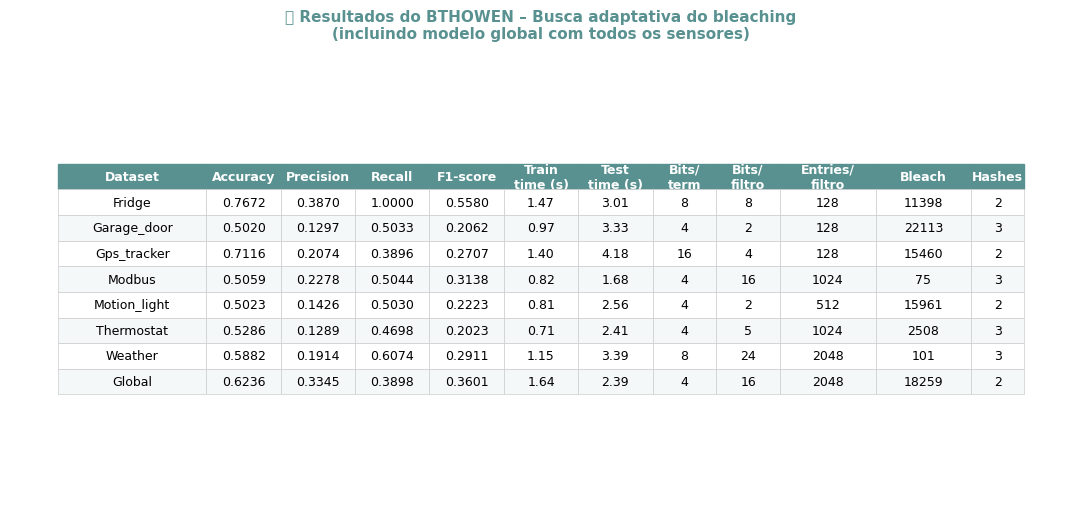

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Dados originais
data_individual = [
    ["Fridge", 0.7672, 0.3870, 1.0000, 0.5580, 1.47, 3.01, 8, 8, 128, 11398, 2],
    ["Garage_door", 0.5020, 0.1297, 0.5033, 0.2062, 0.97, 3.33, 4, 2, 128, 22113, 3],
    ["Gps_tracker", 0.7116, 0.2074, 0.3896, 0.2707, 1.40, 4.18, 16, 4, 128, 15460, 2],
    ["Modbus", 0.5059, 0.2278, 0.5044, 0.3138, 0.82, 1.68, 4, 16, 1024, 75, 3],
    ["Motion_light", 0.5023, 0.1426, 0.5030, 0.2223, 0.81, 2.56, 4, 2, 512, 15961, 2],
    ["Thermostat", 0.5286, 0.1289, 0.4698, 0.2023, 0.71, 2.41, 4, 5, 1024, 2508, 3],
    ["Weather", 0.5882, 0.1914, 0.6074, 0.2911, 1.15, 3.39, 8, 24, 2048, 101, 3],
]

# Dados do modelo global
data_global = [
    ["Global", 0.6236, 0.3345, 0.3898, 0.3601, 1.64, 2.39, 4, 16, 2048, 18259, 2]
]

data = data_individual + data_global

col_labels = [
    "Dataset", "Accuracy", "Precision", "Recall", "F1-score",
    "Train\ntime (s)", "Test\ntime (s)",
    "Bits/\nterm", "Bits/\nfiltro", "Entries/\nfiltro", "Bleach", "Hashes"
]

col_widths = [0.14, 0.07, 0.07, 0.07, 0.07, 0.07, 0.07, 0.06, 0.06, 0.09, 0.09, 0.05]

table_data = []
for row in data:
    formatted = [
        row[0],
        f"{row[1]:.4f}",
        f"{row[2]:.4f}",
        f"{row[3]:.4f}",
        f"{row[4]:.4f}",
        f"{row[5]:.2f}",
        f"{row[6]:.2f}",
        str(row[7]),
        str(row[8]),
        str(row[9]),
        str(row[10]),
        str(row[11])
    ]
    table_data.append(formatted)

COR_HEADER = '#599191'
COR_ZEBRA = '#f4f8f8'
COR_LINHA_IMPAR = '#ffffff'

fig_width = sum(col_widths) * 12
fig_height = len(data) * 0.5 + 1.2

fig, ax = plt.subplots(figsize=(fig_width, fig_height))
ax.axis('off')

table = ax.table(cellText=table_data, colLabels=col_labels, loc='center',
                 cellLoc='center', colWidths=col_widths)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.4)

for (row, col), cell in table.get_celld().items():
    if row == 0:  # cabeçalho
        cell.set_facecolor(COR_HEADER)
        cell.set_text_props(color='white', weight='bold')
        cell.set_edgecolor(COR_HEADER)
    else:
        if row % 2 == 0:
            cell.set_facecolor(COR_ZEBRA)
        else:
            cell.set_facecolor(COR_LINHA_IMPAR)
        cell.set_edgecolor('#cccccc')
        cell.set_linewidth(0.5)

ax.set_title('📊 Resultados do BTHOWEN – Busca adaptativa do bleaching\n(incluindo modelo global com todos os sensores)',
             fontsize=11, fontweight='bold', color=COR_HEADER, pad=15)

plt.tight_layout()
plt.savefig('tabela_bthowen_com_global.png', dpi=200, bbox_inches='tight')
plt.show()